In [ ]:
from google.colab import drive
drive.mount('/content/gdrive')

Mounted at /content/gdrive


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly as py
import plotly.graph_objs as go
from sklearn.cluster import KMeans
import warnings
warnings.filterwarnings("ignore")

#Data Exploration

Trong phần này, em tiến hành kiểm tra dữ liệu, kiểm tra các giá trị null, loại dữ liệu đối tượng và những thứ khác để giữ cho dữ liệu sạch sẽ và có cấu trúc tốt.

In [ ]:
#Đọc csv và in 5 hàng đầu tiên
df = pd.read_csv("/content/gdrive/My Drive/Data/Mall_Customers.csv")
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [ ]:
#Kiểm tra kích thước bộ dữ liệu
df.shape

(200, 5)

Tên của một số cột khá phức tạp và có thể được thay đổi thành một tên đơn giản hơn để có thể truy cập dữ liệu dễ dàng hơn.

In [ ]:
#Thay đổi tên của một số cột
df = df.rename(columns={'Annual Income (k$)': 'Annual_income', 'Spending Score (1-100)': 'Spending_score'})

In [ ]:
#Tìm kiếm giá trị null
df.isna().sum()

CustomerID        0
Gender            0
Age               0
Annual_income     0
Spending_score    0
dtype: int64

In [ ]:
#Kiểm tra kiểu dữ liệu
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   CustomerID      200 non-null    int64 
 1   Gender          200 non-null    object
 2   Age             200 non-null    int64 
 3   Annual_income   200 non-null    int64 
 4   Spending_score  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


Vì Giới tính không phải là một giá trị số mà là một đối tượng, nên em sẽ thay thế các giá trị này. Nữ sẽ là 0 và Nam sẽ là 1

In [ ]:
#Thay thế các đối tượng cho các giá trị số
df['Gender'].replace(['Female','Male'], [0,1],inplace=True)

In [ ]:
#Kiểm tra các giá trị đã được thay thế
df.Gender

0      1
1      1
2      0
3      0
4      0
      ..
195    0
196    0
197    1
198    1
199    1
Name: Gender, Length: 200, dtype: int64

#Trực quan hóa dữ liệu
Trực quan hóa dữ liệu và vẽ biểu đồ thông tin quan trọng để có thể thấy các giá trị khác nhau mà dữ liệu có. Để làm như vậy, em sẽ chỉ xem xét các tính năng sau: Thu nhập_hàng năm, Điểm số chi tiêu và Độ tuổi. Giới tính sẽ chỉ được sử dụng để phân tách dữ liệu để có thể phân biệt giá trị cho nam và nữ.

Để bắt đầu, vẽ biểu đồ cho từng tính năng trong số ba tính năng Thu nhập_hàng năm, Điểm số chi tiêu và Độ tuổi

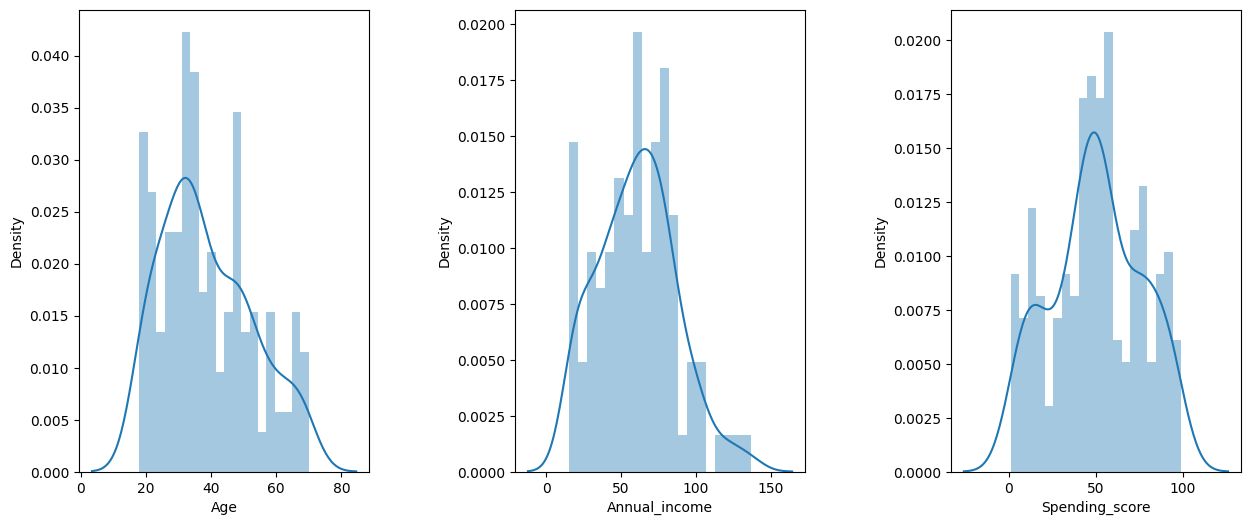

In [ ]:
# Ước tính mật độ của các giá trị bằng distplot
plt.figure(1 , figsize = (15 , 6))
feature_list = ['Age','Annual_income', "Spending_score"]
feature_listt = ['Age','Annual_income', "Spending_score"]
pos = 1
for i in feature_list:
    plt.subplot(1 , 3 , pos)
    plt.subplots_adjust(hspace = 0.5 , wspace = 0.5)
    sns.distplot(df[i], bins=20, kde = True)
    pos = pos + 1
plt.show()

0    112
1     88
Name: Gender, dtype: int64

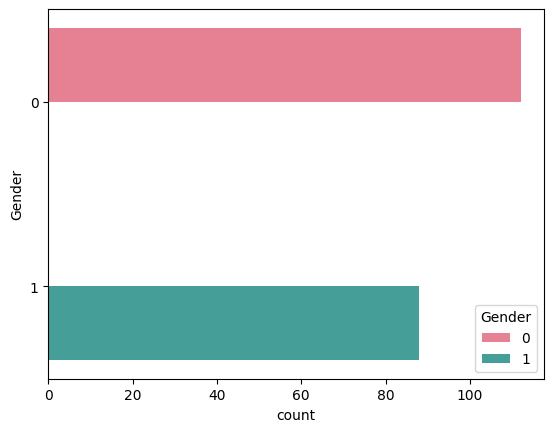

In [ ]:
#Count and plot gender
sns.countplot(y = 'Gender', data = df, palette="husl", hue = "Gender")
df["Gender"].value_counts()

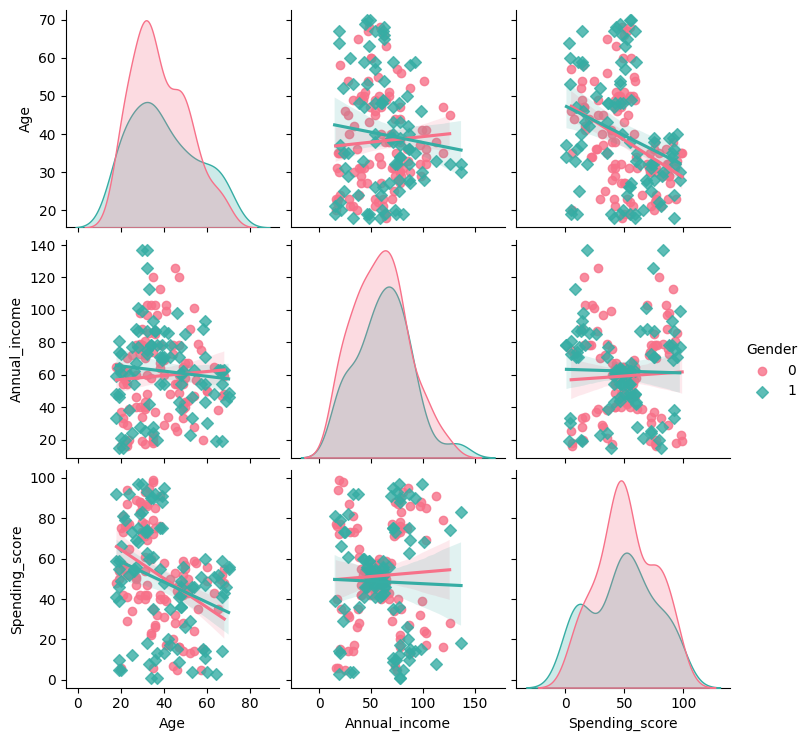

In [ ]:
#Pairplot với các biến muốn dùng để phân tích
sns.pairplot(df, vars=["Age", "Annual_income", "Spending_score"],  kind ="reg", hue = "Gender", palette="husl", markers = ['o','D'])

Tiếp theo để có thể nhìn tổng quan dữ liệu và mối tương quan giữa các chiều dữ liệu theo từng cặp với nhau, thì ở đây chúng em sẽ chọn Pairplots. Các điểm dữ liệu cho ta thấy được sự phân tán của dữ liệu, đường thẳng chính là đường hồi quy tuyến tính (biểu diễn mối quan hệ giữa 2 biến, cụ thể ở đây là các cặp trường dữ liệu)
-	Dựa vào biểu đồ trên ta thấy sự quan giữa 2 trường dữ liệu là Age và Anual Income là khá tương đối, đặc biệt là tương quan cao ở Nam giới (đường màu xanh lá) thu nhập hằng năm (Annual Income) có xu hướng giảm khi mà độ tuổi tăng dần (cụ thể ở đây là tương quan nghịch). Còn đối với giới tính Nữ (màu đỏ) thì sự tương quan này là không cao nhưng có xu hướng ngược lại, thu nhập có xu hướng tăng khi độ tuổi tăng lên (tương quan thuận).
-	Tiếp đến là sự tương quan giữa 2 trường Age và Spending Score, rõ ràng từ biểu đồ ta có thể thấy cả 2 đường hồi quy giữa 2 trường dữ liệu này ở cả 2 giới tính đều có giá trị tuyệt đối của hệ số góc rất cao |k| ~ 1, cho sự tương quan chặt chẽ giữa 2 trường dữ liệu này, cụ thể là Spending Score giảm đều khi độ tuổi tăng lên ở cả 2 giới tính ( đây là tương quan nghịch cao).
-	Và sau cùng là giữa trường Spending Score và Anual Income, thì ở đây ta thấy sự tương quan giữa 2 biến này là tương đối thấp vì cả 2 đường hồi quy có xu hướng song song với trục hoành, vì vậy ta có thể thấy Thu nhập hằng năm không ảnh hưởng nhiều đến Spending Score và nhìn vào sự phân bố của các điểm dữ liệu, ta thấy sự tương quan này tương đồng ở cả 2 giới tính.


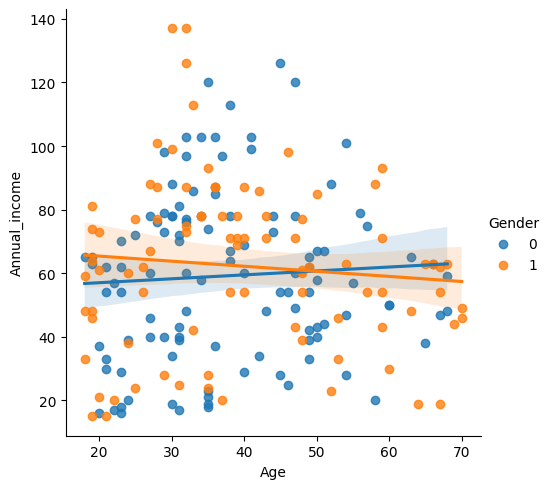

In [ ]:
#Age and Annual Income
sns.lmplot(x = "Age", y = "Annual_income", data = df, hue = "Gender")

Chúng ta có thể thấy từ biểu đồ 2 đường hồi quy giữa 2 trường dữ liệu qua hai giới tính có hệ số góc không quá lớn nên sự tương quan này không quá lớn. Từ đó ta có thể thấy những người ở độ tuổi 30, 40 và 50 có xu hướng kiếm được nhiều tiền hơn hàng năm so với những người dưới 30 tuổi hoặc trên 50 tuổi. Những người có độ tuổi nằm trong khoảng từ 30 đến 50 tuổi dường như kiếm được công việc tốt hơn vì họ chuẩn bị tốt hơn hoặc đã có nhiều kinh nghiệm hơn những người trẻ tuổi hoặc những người lớn tuổi hơn. Trong biểu đồ, chúng ta cũng có thể thấy nam giới có xu hướng kiếm được nhiều tiền hơn một chút so với nữ giới, ít nhất là cho đến năm mươi tuổi.

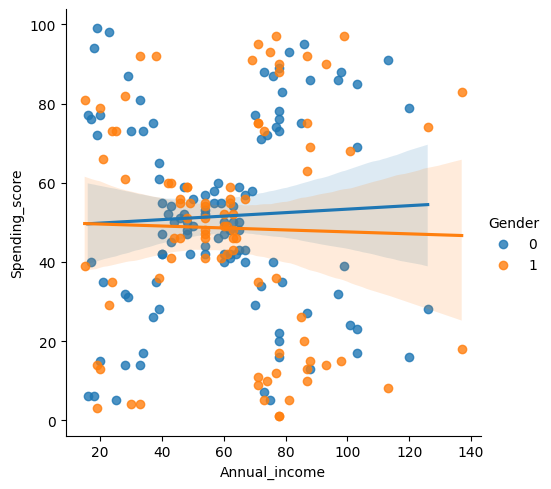

In [ ]:
#Spending Score and Annual Income
sns.lmplot(x = "Annual_income", y = "Spending_score", data = df, hue = "Gender")

Ở đây chúng ta có thể quan sát thu nhập hàng năm tốt hơn dẫn đến việc có điểm chi tiêu cao hơn, đặc biệt đối với phụ nữ. Tuy nhiên, mối tương quan giữa hai biến số này không quá lớn, phần lớn những người ở mức trung bình, những người có mức lương khá và có điểm chi tiêu khá cao.

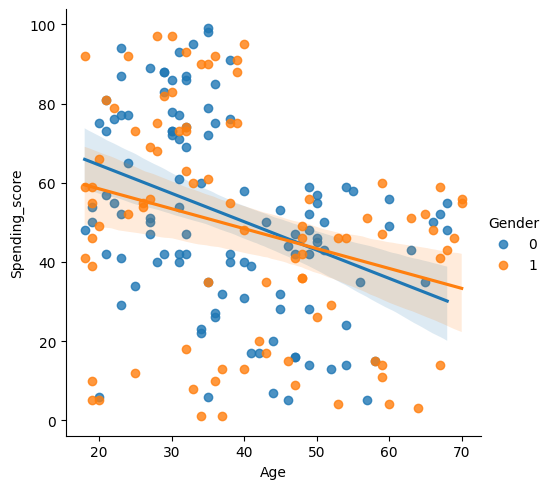

In [ ]:
#Age and Spending Score
sns.lmplot(x = "Age", y = "Spending_score", data = df, hue = "Gender")

Trong hình cuối cùng này, những người trẻ tuổi có xu hướng chi tiêu nhiều hơn những người lớn tuổi. Điều đó có thể do nhiều nguyên nhân: người trẻ thường có nhiều thời gian rảnh rỗi hơn người già, các trung tâm mua sắm thường có các cửa hàng hướng đến giới trẻ như trò chơi điện tử, cửa hàng công nghệ, v.v.

#Selecting Number of Clusters
Bây giờ chúng ta đã hiểu một chút về tập dữ liệu này, quyết định số lượng cụm mà chúng ta muốn chia dữ liệu của mình. Để làm như vậy, chúng ta sẽ sử dụng Elbow Method

In [ ]:
#Tạo giá trị cho the elbow
X = df.loc[:,["Age", "Annual_income", "Spending_score"]]
inertia = []
k = range(1,20)
for i in k:
    means_k = KMeans(n_clusters=i, random_state=0)
    means_k.fit(X)
    inertia.append(means_k.inertia_)

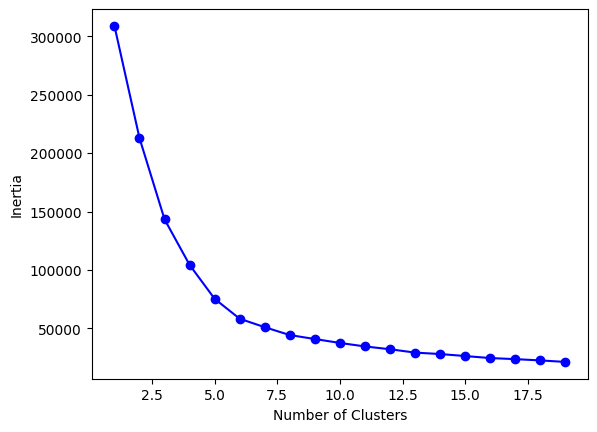

In [ ]:
#Plotting the elbow
plt.plot(k , inertia , 'bo-')
plt.xlabel('Number of Clusters') , plt.ylabel('Inertia')
plt.show()

The elbow method được sử dụng để xác định số cụm tối ưu trong phân cụm k-mean. The elbow method vẽ sơ đồ giá trị của hàm chi phí được tạo bởi các giá trị khác nhau của k và người ta nên chọn một số cụm sao cho việc thêm một cụm khác không mang lại mô hình dữ liệu tốt hơn nhiều. Trong vấn đề này, Nhóm em đang sử dụng quán tính làm hàm chi phí để xác định tổng bình phương khoảng cách của các mẫu đến trung tâm cụm gần nhất.

#Phân cụm
Trong quá trình phân cụm chúng ta sẽ không xét đến yếu tố giới tính. Lý do chính đầu tiên vì sự khác biệt giữa nam và nữ trong dữ liệu này không đặc biệt lớn và việc tạo ra sự khác biệt về giới tính sẽ không cung cấp thêm thông tin nào. Lý do thứ hai và không kém phần quan trọng là thực tế là các cửa hàng nói chung hầu như không còn nhắm mục tiêu đến một giới tính cụ thể nữa, hầu hết các cửa hàng trong trung tâm mua sắm đều có thể tìm thấy các sản phẩm dành cho nam và nữ.

In [ ]:
#Training kmeans với 5 cụm
means_k = KMeans(n_clusters=5, random_state=0)
means_k.fit(X)
labels = means_k.labels_
centroids = means_k.cluster_centers_

Như chúng ta có thể quan sát, thuật toán K-means đã hoàn tất và tiếp theo đây chúng ta vẽ biểu đồ kết quả mà chúng ta thu được từ nó để có thể hình dung các cụm khác nhau và phân nhóm chúng.

In [ ]:
#Tạo biểu đồ 3d để xem phân tách dữ liệu do Kmeans thực hiện
trace1 = go.Scatter3d(
    x= X['Spending_score'],
    y= X['Annual_income'],
    z= X['Age'],
    mode='markers',
     marker=dict(
        color = labels,
        size= 10,
        line=dict(
            color= labels,
        ),
        opacity = 0.9
     )
)
layout = go.Layout(
    title= 'Clusters',
    scene = dict(
            xaxis = dict(title  = 'Spending_score'),
            yaxis = dict(title  = 'Annual_income'),
            zaxis = dict(title  = 'Age')
        )
)
fig = go.Figure(data=trace1, layout=layout)
py.offline.iplot(fig)

Sau khi vẽ các kết quả thu được bằng K-means trên biểu đồ 3D Plot,
 chúng ta xác định và mô tả năm cụm đã được tạo:

Nhóm màu vàng - Bao gồm những người trẻ tuổi có thu nhập hàng năm từ trung bình đến thấp, những người thực sự chi tiêu nhiều.

Nhóm màu tím - Tập hợp những người trẻ tuổi hợp lý với mức lương khá, những người chi tiêu nhiều.

Nhóm màu hồng -  Tập hợp những người ở mọi lứa tuổi có mức lương không cao và điểm chi tiêu của họ ở mức trung bình.

Nhóm màu cam - Tập hợp những người thực sự có mức lương khá tốt và hầu như không tiêu tiền, tuổi của họ thường nằm trong khoảng từ ba mươi đến sáu mươi tuổi.

Nhóm màu xanh -  Có mức lương khá thấp và không tiêu nhiều tiền vào cửa hàng, họ là những người ở mọi lứa tuổi.